In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib
#To remove warnings
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [2]:
df = pd.read_csv('data1.csv')

In [3]:
df.describe()

,Model year,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
count,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000
mean,2021.864456,3.166192,5.660583,12.482239,9.333497,11.065146,27.310706,258.228578,4.465168,4.943468
std,1.381764,1.350129,1.945803,3.454828,2.253716,2.862555,7.608700,63.984161,1.502580,1.734596
min,2020.000000,1.000000,3.000000,4.000000,3.900000,4.000000,11.000000,94.000000,1.000000,1.000000
25%,2021.000000,2.000000,4.000000,10.100000,7.700000,9.100000,22.000000,213.000000,3.000000,3.000000
50%,2022.000000,3.000000,6.000000,12.200000,9.100000,10.800000,26.000000,256.000000,4.000000,5.000000
75%,2023.000000,3.800000,6.000000,14.600000,10.700000,12.800000,31.000000,299.000000,5.000000,6.000000
max,2024.000000,8.000000,16.000000,30.300000,20.900000,26.100000,71.000000,608.000000,10.000000,8.000000


In [4]:
df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,2024,Acura,Integra A-SPEC,Full-size,1.5,4,AV7,Z,8.1,6.5,7.4,38,172,6,7
1,2024,Acura,Integra A-SPEC,Full-size,1.5,4,M6,Z,8.9,6.5,7.8,36,181,6,6
2,2024,Acura,Integra Type S,Full-size,2.0,4,M6,Z,11.1,8.3,9.9,29,230,5,6
3,2024,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263,4,5
4,2024,Acura,MDX SH-AWD Type S,Sport utility vehicle: Standard,3.0,6,AS10,Z,13.8,11.2,12.4,23,291,4,5


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4493 entries, 0 to 4492
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model year            4493 non-null   int64  
 1   Make                  4493 non-null   object 
 2   Model                 4493 non-null   object 
 3   Vehicle class         4493 non-null   object 
 4   Engine size (L)       4493 non-null   float64
 5   Cylinders             4493 non-null   int64  
 6   Transmission          4493 non-null   object 
 7   Fuel type             4493 non-null   object 
 8   City (L/100 km)       4493 non-null   float64
 9   Highway (L/100 km)    4493 non-null   float64
 10  Combined (L/100 km)   4493 non-null   float64
 11  Combined (mpg)        4493 non-null   int64  
 12  CO2 emissions (g/km)  4493 non-null   int64  
 13  CO2 rating            4493 non-null   int64  
 14  Smog rating           4493 non-null   int64  
dtypes: float64(4), int64(

In [11]:
df.isna().sum()

Model year              0
Make                    0
Model                   0
Vehicle class           0
Engine size (L)         0
Cylinders               0
Transmission            0
Fuel type               0
City (L/100 km)         0
Highway (L/100 km)      0
Combined (L/100 km)     0
Combined (mpg)          0
CO2 emissions (g/km)    0
CO2 rating              0
Smog rating             0
dtype: int64

In [10]:
list(df.select_dtypes(include='object'))

['Make', 'Model', 'Vehicle class', 'Transmission', 'Fuel type']

In [12]:
df['Make'].unique()

array(['Acura', 'Alfa Romeo', 'Aston Martin', 'Audi', 'Bentley', 'BMW',
       'Bugatti', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge',
       'Ferrari', 'Ford', 'Genesis', 'GMC', 'Honda', 'Hyundai',
       'Infiniti', 'Jaguar', 'Jeep', 'Kia', 'Lamborghini', 'Land Rover',
       'Lexus', 'Lincoln', 'Maserati', 'Mazda', 'Mercedes-Benz', 'MINI',
       'Mitsubishi', 'Nissan', 'Porsche', 'Ram', 'Rolls-Royce', 'Subaru',
       'Toyota', 'Volkswagen', 'Volvo', 'FIAT'], dtype=object)

In [13]:
df['Model'].unique()

array(['Integra A-SPEC', 'Integra Type S', 'MDX SH-AWD', ..., 'Yaris',
       'Yaris (SIL)', 'XC40 T4'], dtype=object)

In [14]:
df['Vehicle class'].unique()

array(['Full-size', 'Sport utility vehicle: Small',
       'Sport utility vehicle: Standard', 'Mid-size', 'Minicompact',
       'Two-seater', 'Subcompact', 'Compact', 'Station wagon: Small',
       'Station wagon: Mid-size', 'Pickup truck: Small',
       'Pickup truck: Standard', 'Minivan', 'Special purpose vehicle',
       'Van: Passenger'], dtype=object)

In [15]:
df['Transmission'].unique()

array(['AV7', 'M6', 'AS10', 'A8', 'A9', 'AM7', 'AS8', 'AM8', 'AV', 'A6',
       'A10', 'AS9', 'M7', 'AV1', 'AM6', 'AS7', 'AV8', 'AV6', 'AS6',
       'AV10', 'M5', 'AS5', 'A7', 'AM9', 'A5', 'A4'], dtype=object)

In [16]:
df['Fuel type'].unique()

array(['Z', 'X', 'D', 'E'], dtype=object)

In [17]:
onehot = OneHotEncoder()
encoder_df = pd.DataFrame(onehot.fit_transform(df[['Fuel type']]).toarray())
df = df.join(encoder_df)

In [18]:
df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating,0,1,2,3
0,2024,Acura,Integra A-SPEC,Full-size,1.5,4,AV7,Z,8.1,6.5,7.4,38,172,6,7,0.0,0.0,0.0,1.0
1,2024,Acura,Integra A-SPEC,Full-size,1.5,4,M6,Z,8.9,6.5,7.8,36,181,6,6,0.0,0.0,0.0,1.0
2,2024,Acura,Integra Type S,Full-size,2.0,4,M6,Z,11.1,8.3,9.9,29,230,5,6,0.0,0.0,0.0,1.0
3,2024,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263,4,5,0.0,0.0,0.0,1.0
4,2024,Acura,MDX SH-AWD Type S,Sport utility vehicle: Standard,3.0,6,AS10,Z,13.8,11.2,12.4,23,291,4,5,0.0,0.0,0.0,1.0


In [19]:
filtered_df = df[df['Fuel type'] == 'D'].head()

print(filtered_df)

     Model year       Make                            Model  \
132        2024   Cadillac                     Escalade 4WD   
166        2024  Chevrolet                        Silverado   
174        2024  Chevrolet                    Silverado 4WD   
175        2024  Chevrolet  Silverado 4WD (With Sport Mode)   
176        2024  Chevrolet   Silverado 4WD Mud Terrain Tire   

                       Vehicle class  Engine size (L)  Cylinders Transmission  \
132  Sport utility vehicle: Standard              3.0          6          A10   
166           Pickup truck: Standard              3.0          6          A10   
174           Pickup truck: Standard              3.0          6          A10   
175           Pickup truck: Standard              3.0          6          A10   
176           Pickup truck: Standard              3.0          6          A10   

    Fuel type  City (L/100 km)  Highway (L/100 km)  Combined (L/100 km)  \
132         D             11.7                 9.0         

In [20]:
filtered_df = df[df['Fuel type'] == 'X'].head()

print(filtered_df)

     Model year        Make               Model  \
13         2024  Alfa Romeo          Tonale AWD   
19         2024        Audi  A3 40 TFSI quattro   
30         2024        Audi  Q3 40 TFSI quattro   
31         2024        Audi  Q3 45 TFSI quattro   
112        2024       Buick         Enclave AWD   

                       Vehicle class  Engine size (L)  Cylinders Transmission  \
13      Sport utility vehicle: Small              2.0          4           A9   
19                        Subcompact              2.0          4          AM7   
30      Sport utility vehicle: Small              2.0          4          AS8   
31      Sport utility vehicle: Small              2.0          4          AS8   
112  Sport utility vehicle: Standard              3.6          6           A9   

    Fuel type  City (L/100 km)  Highway (L/100 km)  Combined (L/100 km)  \
13          X             11.2                 8.2                  9.8   
19          X              9.2                 6.9      

In [21]:
filtered_df = df[df['Fuel type'] == 'E'].head()

print(filtered_df)

     Model year       Make                               Model  \
169        2024  Chevrolet                       Silverado FFV   
179        2024  Chevrolet                   Silverado 4WD FFV   
182        2024  Chevrolet  Silverado 4WD Mud Terrain Tire FFV   
288        2024        GMC                          Sierra FFV   
296        2024        GMC                      Sierra 4WD FFV   

              Vehicle class  Engine size (L)  Cylinders Transmission  \
169  Pickup truck: Standard              5.3          8          A10   
179  Pickup truck: Standard              5.3          8          A10   
182  Pickup truck: Standard              5.3          8          A10   
288  Pickup truck: Standard              5.3          8          A10   
296  Pickup truck: Standard              5.3          8          A10   

    Fuel type  City (L/100 km)  Highway (L/100 km)  Combined (L/100 km)  \
169         E             19.6                15.3                 17.7   
179         E       

In [22]:
df.rename(columns = {0:'D',1:'E', 2:'X', 3:'Z'}, inplace = True)

In [23]:
df = df.drop(['Fuel type'], axis=1)

In [24]:
label_encoder = LabelEncoder()
df['Model']= label_encoder.fit_transform(df['Model']) 
df['Vehicle class']= label_encoder.fit_transform(df['Vehicle class']) 
df['Transmission']= label_encoder.fit_transform(df['Transmission']) 
df['Make']= label_encoder.fit_transform(df['Make']) 

In [27]:
df.corr()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating,D,E,X,Z
Model year,1.000000,0.003882,0.006939,0.030768,-0.019366,-0.026223,0.003996,-0.008488,0.035658,0.007175,-0.001139,0.014262,0.018473,0.198633,0.002639,-0.029815,-0.008937,0.015561
Make,0.003882,1.000000,-0.178716,-0.103927,-0.185820,-0.193540,0.231679,-0.217773,-0.202390,-0.216115,0.232177,-0.212888,0.225131,0.124365,-0.067691,-0.077660,0.123798,-0.082492
Model,0.006939,-0.178716,1.000000,0.092863,0.044079,0.025734,-0.072476,0.008561,0.072289,0.031150,-0.026072,0.021241,-0.038995,0.070672,0.090524,0.078040,0.084070,-0.131974
Vehicle class,0.030768,-0.103927,0.092863,1.000000,0.120392,0.119270,-0.075990,0.198756,0.251397,0.220542,-0.240619,0.228796,-0.227929,-0.099482,0.022331,0.008911,-0.080328,0.070762
Engine size (L),-0.019366,-0.185820,0.044079,0.120392,1.000000,0.919665,-0.319879,0.828782,0.734494,0.810073,-0.700970,0.812536,-0.759199,-0.490610,-0.023084,0.133309,-0.220463,0.193522
Cylinders,-0.026223,-0.193540,0.025734,0.119270,0.919665,1.000000,-0.284060,0.836813,0.725021,0.812046,-0.691342,0.822713,-0.755908,-0.527474,0.006543,0.106076,-0.318300,0.288506
Transmission,0.003996,0.231679,-0.072476,-0.075990,-0.319879,-0.284060,1.000000,-0.302327,-0.342183,-0.322174,0.311530,-0.336037,0.335714,0.093040,-0.235664,-0.093797,0.035384,0.062727
City (L/100 km),-0.008488,-0.217773,0.008561,0.198756,0.828782,0.836813,-0.302327,1.000000,0.921396,0.990311,-0.911605,0.963197,-0.913786,-0.541161,-0.059425,0.276135,-0.352279,0.300496
Highway (L/100 km),0.035658,-0.202390,0.072289,0.251397,0.734494,0.725021,-0.342183,0.921396,1.000000,0.966158,-0.878855,0.931395,-0.880194,-0.425699,-0.045875,0.310518,-0.247355,0.183016
Combined (L/100 km),0.007175,-0.216115,0.031150,0.220542,0.810073,0.812046,-0.322174,0.990311,0.966158,1.000000,-0.916726,0.969555,-0.918648,-0.510451,-0.055143,0.293656,-0.321496,0.264066


<Axes: >

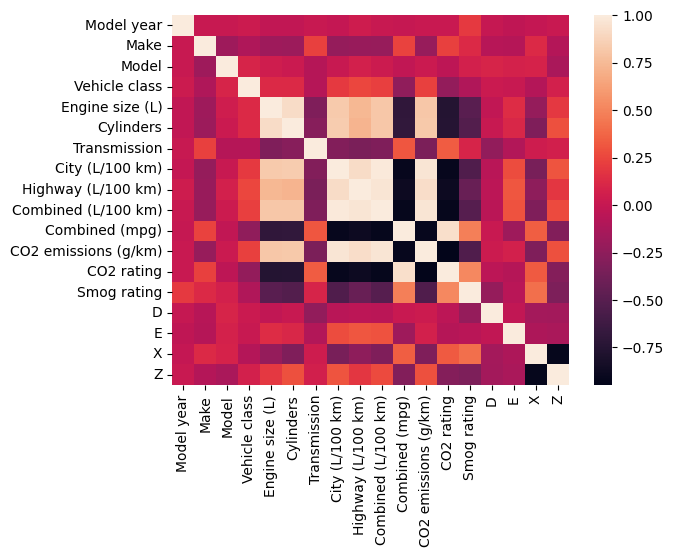

In [28]:
sns.heatmap(df.corr())

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4493 entries, 0 to 4492
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model year            4493 non-null   int64  
 1   Make                  4493 non-null   int32  
 2   Model                 4493 non-null   int32  
 3   Vehicle class         4493 non-null   int32  
 4   Engine size (L)       4493 non-null   float64
 5   Cylinders             4493 non-null   int64  
 6   Transmission          4493 non-null   int32  
 7   City (L/100 km)       4493 non-null   float64
 8   Highway (L/100 km)    4493 non-null   float64
 9   Combined (L/100 km)   4493 non-null   float64
 10  Combined (mpg)        4493 non-null   int64  
 11  CO2 emissions (g/km)  4493 non-null   int64  
 12  CO2 rating            4493 non-null   int64  
 13  Smog rating           4493 non-null   int64  
 14  D                     4493 non-null   float64
 15  E                    

In [31]:
df.columns

Index(['Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)',
       'Cylinders', 'Transmission', 'City (L/100 km)', 'Highway (L/100 km)',
       'Combined (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)',
       'CO2 rating', 'Smog rating', 'D', 'E', 'X', 'Z'],
      dtype='object')

In [32]:
X=df[[ 'Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)',
       'Cylinders', 'Transmission', 'City (L/100 km)', 'Highway (L/100 km)',
       'Combined (L/100 km)', 'Combined (mpg)', 
       'CO2 rating', 'Smog rating', 'D', 'E', 'X', 'Z' 
       ]]
    
y=df['CO2 emissions (g/km)']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [34]:
linear = LinearRegression()
linear.fit(X_train,y_train)
linear.score(X_test, y_test)

0.9984566353702442

In [35]:
decision = DecisionTreeRegressor()
decision.fit(X_train,y_train)
decision.score(X_test,y_test)

0.9957284437189167

In [36]:
random = RandomForestRegressor()
random.fit(X_train,y_train)
random.score(X_test,y_test)

0.9984736857791027

In [47]:
#Cross Validation Score, to check for overfitting, and get a generalized accuracy
from sklearn.model_selection import cross_val_score
score_lr=cross_val_score(LinearRegression(),X,y,cv=10)
print(score_lr)
print("Avg :",np.average(score_lr))

[0.99912853 0.99924449 0.99851595 0.99896638 0.99752458 0.99895242
 0.99698016 0.99923281 0.99634457 0.99917407]
Avg : 0.9984063950317295


In [48]:

score_dt=cross_val_score(DecisionTreeRegressor(),X,y,cv=10)
print(score_dt)
print("Avg :",np.average(score_dt))

[0.99766521 0.99722706 0.99928902 0.99946389 0.97690848 0.99013097
 0.99854716 0.997443   0.98684319 0.99897683]
Avg : 0.9942494822992332


In [49]:
score_rf=cross_val_score(RandomForestRegressor(),X,y,cv=10)
print(score_rf)
print("Avg :",np.average(score_rf))

[0.99819856 0.99917698 0.99937343 0.99846352 0.99794126 0.9976507
 0.9985043  0.99958214 0.99315385 0.99927269]
Avg : 0.9981317449237375
